# Convex Sets and Functions: 3D Visualizations

This notebook provides interactive 3D visualizations of convex sets (ellipsoids, convex hulls, pyramids) and convex functions (quadratics, log-sum-exp, geometric mean, log-determinant). Seeing these objects in three dimensions builds geometric intuition that is hard to develop from definitions alone.

**Learning objectives.** After working through this notebook you should be able to:
1. Visualize common convex sets (ellipsoids, polytopes, convex hulls) in 3D and understand their defining properties.
2. Recognize convex and concave functions from their 3D surface plots.
3. Understand supporting hyperplanes geometrically as tangent planes to convex sets.
4. Relate the first-order Taylor approximation to the surface of a convex function.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
kwargs = {'linewidth' : 2.5}
font = {'weight' : 'normal',
        'size'   : 16}
matplotlib.rc('font', **font)

## Ellipsoids as Convex Sets

An **ellipsoid** in $\mathbb{R}^3$ is a set of the form

$$
\mathcal{E} = \left\{ (x,y,z) \colon \frac{x^2}{a^2} + \frac{y^2}{b^2} + \frac{z^2}{c^2} \leq 1 \right\},
$$

where $a, b, c > 0$ are the semi-axis lengths. Ellipsoids are convex because they are sublevel sets of a convex (positive definite quadratic) function. When $a = b = c$ the ellipsoid reduces to a ball. Below we plot ellipsoids with different axis ratios to see how the shape stretches along each coordinate.

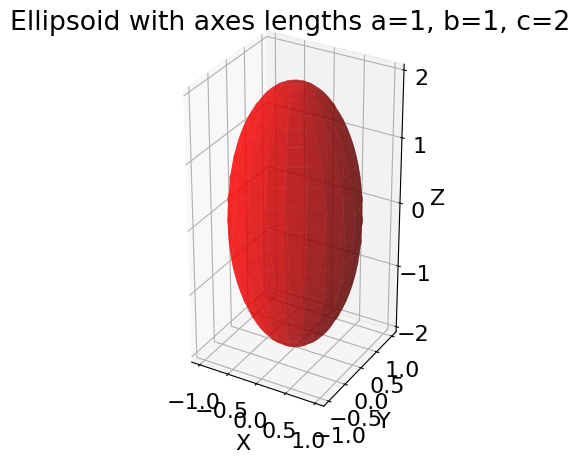

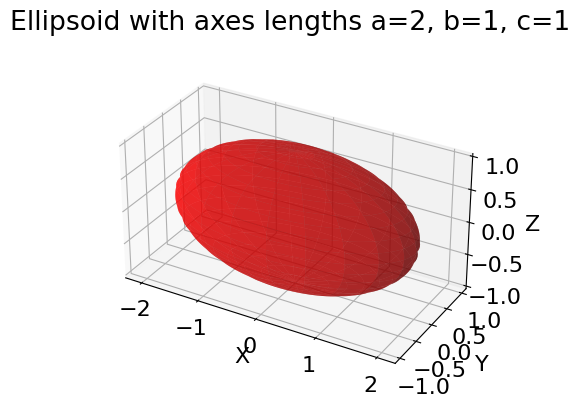

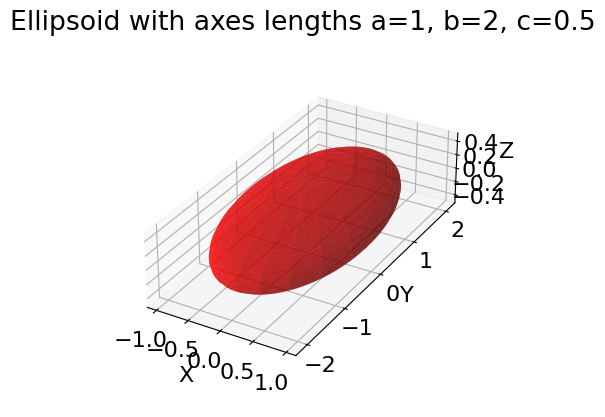

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull


# Plot a convex quadratic set (Ellipsoid) with adjustable axes
def plot_adjusted_ellipsoid(a=1, b=1, c=1):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Create a grid of points for parametric equations
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)

    # Parametric equations for the ellipsoid
    x = a * np.outer(np.cos(u), np.sin(v))
    y = b * np.outer(np.sin(u), np.sin(v))
    z = c * np.outer(np.ones_like(u), np.cos(v))

    # Plot ellipsoid
    ax.plot_surface(x, y, z, color='r', alpha=0.6, rstride=5, cstride=5)

    ax.set_title(f"Ellipsoid with axes lengths a={a}, b={b}, c={c}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # Set equal aspect for better visualization
    ax.set_box_aspect([a, b, c])

# Example usage: Create ellipsoids with different shapes
plot_adjusted_ellipsoid(a=1, b=1, c=2)  # Elongated along z-axis
plt.show()

plot_adjusted_ellipsoid(a=2, b=1, c=1)  # Elongated along x-axis
plt.show()

plot_adjusted_ellipsoid(a=1, b=2, c=0.5)  # Flattened along z-axis
plt.show()


## Convex Hulls

The **convex hull** of a set of points $\{p_1, \ldots, p_k\}$ is the smallest convex set containing all the points:

$$
\operatorname{conv}\{p_1,\ldots,p_k\} = \left\{ \sum_{i=1}^k \lambda_i p_i : \lambda_i \geq 0,\; \sum_i \lambda_i = 1 \right\}.
$$

Below we compute the convex hull of random points in 2D (a convex polygon) and then in 3D (a convex polytope). We also show a square pyramid, whose convex hull is the pyramid itself.

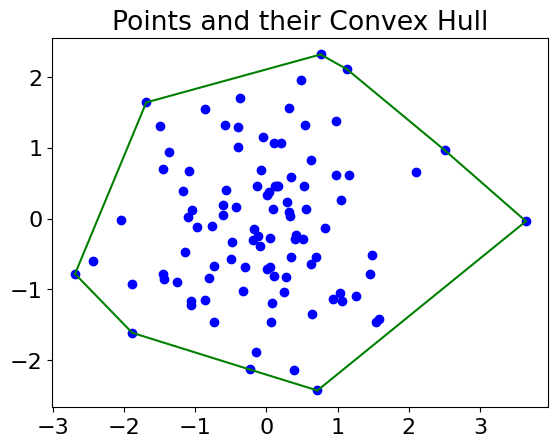

In [4]:


# Generate some random points
points = np.random.randn(100, 2)

# Calculate the convex hull of the points
hull = ConvexHull(points)

# Plot the points
plt.scatter(points[:, 0], points[:, 1], color='blue')

# Plot the convex hull
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'g-')

plt.title("Points and their Convex Hull")
plt.show()


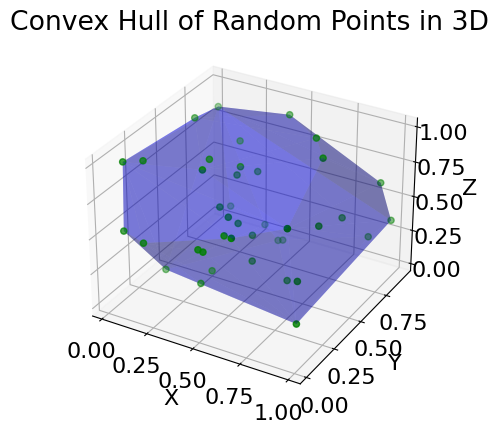

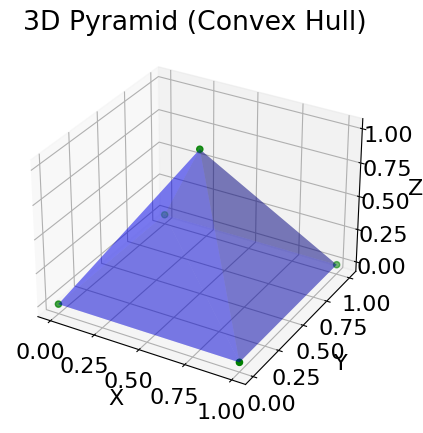

In [5]:


def plot_convex_hull_3d():
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Generate random points in 3D
    points = np.random.rand(40, 3)

    # Compute convex hull
    hull = ConvexHull(points)

    # Plot points
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='g')

    # Plot convex hull
    for simplex in hull.simplices:
        ax.plot_trisurf(points[simplex, 0], points[simplex, 1], points[simplex, 2], color='b', alpha=0.3)

    ax.set_title("Convex Hull of Random Points in 3D")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")



plot_convex_hull_3d()
plt.show()



def plot_pyramid():
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Define 4 points for a square pyramid (base + apex)
    points = np.array([
        [0, 0, 0],  # base point 1
        [1, 0, 0],  # base point 2
        [1, 1, 0],  # base point 3
        [0, 1, 0],  # base point 4
        [0.5, 0.5, 1]  # apex
    ])

    # Compute convex hull
    hull = ConvexHull(points)

    # Plot points
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='g')

    # Plot convex hull (pyramid surface)
    for simplex in hull.simplices:
        ax.plot_trisurf(points[simplex, 0], points[simplex, 1], points[simplex, 2], color='b', alpha=0.3)

    ax.set_title("3D Pyramid (Convex Hull)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

# Plot pyramid
plot_pyramid()
plt.show()



## Supporting Hyperplanes

A **supporting hyperplane** to a convex set $C$ at a boundary point $x_0$ is a hyperplane $\{x : a^\top x = a^\top x_0\}$ such that $a^\top x \leq a^\top x_0$ for all $x \in C$. The supporting hyperplane theorem guarantees that such a hyperplane exists at every boundary point of a convex set.

Below we first visualize tangent lines to an ellipse in 2D, and then tangent planes to an ellipsoid in 3D. At each contact point $x_0$ on the ellipsoid, the outward normal is $n = 2\big(\frac{x_0}{a^2}, \frac{y_0}{b^2}, \frac{z_0}{c^2}\big)$, and the tangent plane passes through $x_0$ perpendicular to $n$.

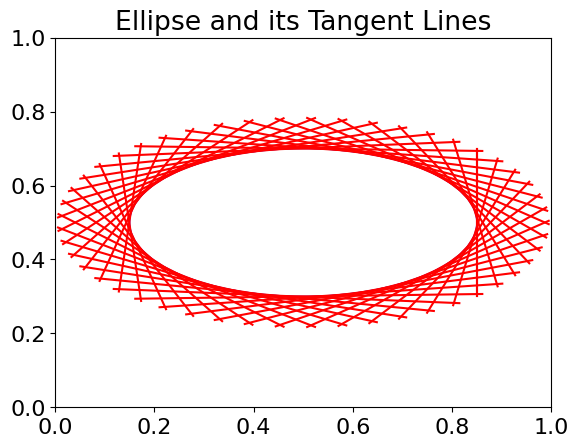

In [6]:
from matplotlib.patches import Ellipse

# Create a new figure and axis
fig, ax = plt.subplots()

# Define the ellipse
ellipse = Ellipse((0.5, 0.5), width=0.7, height=0.4, edgecolor='blue', facecolor='none')

# Add the ellipse to the axis
ax.add_patch(ellipse)

# Plot tangent lines around the ellipse
theta = np.linspace(0, 2*np.pi, 50)
x = 0.5 + 0.35 * np.cos(theta)
y = 0.5 + 0.2 * np.sin(theta)
dx = -0.35 * np.sin(theta)
dy = 0.2 * np.cos(theta)

for i in range(len(x)):
    ax.plot([x[i] - 1*dx[i], x[i] + 1*dx[i]], [y[i] - 1*dy[i], y[i] + 1*dy[i]], 'r-')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title("Ellipse and its Tangent Lines")
plt.show()


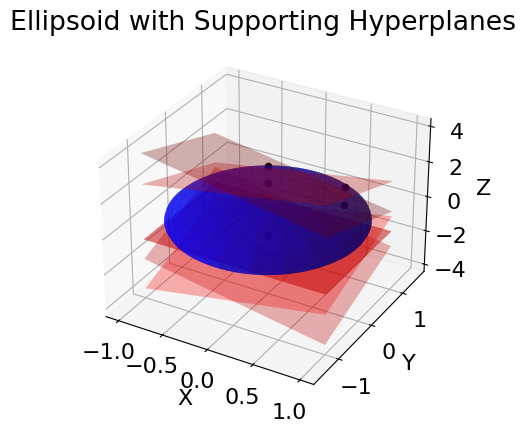

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Plot an ellipsoid and supporting hyperplanes in 3D
def plot_ellipsoid_with_hyperplanes(a=1, b=1, c=1):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Parametric equations for the ellipsoid
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = a * np.outer(np.cos(u), np.sin(v))
    y = b * np.outer(np.sin(u), np.sin(v))
    z = c * np.outer(np.ones_like(u), np.cos(v))

    # Plot the ellipsoid
    ax.plot_surface(x, y, z, color='b', alpha=0.6, rstride=5, cstride=5)

    # Define some points on the ellipsoid where we will add hyperplanes
    phi = np.array([np.pi/3, 2* np.pi/3, np.pi])
    theta = np.array([np.pi/3, 2 * np.pi/3])

    # Supporting hyperplanes (approximated at some points on the ellipsoid)
    for p in phi:
        for t in theta:
            x0 = a * np.cos(t) * np.sin(p)
            y0 = b * np.sin(t) * np.sin(p)
            z0 = c * np.cos(p)

            # Normal vector to the ellipsoid at this point
            normal = np.array([2*x0/a**2, 2*y0/b**2, 2*z0/c**2])
            normal /= np.linalg.norm(normal)

            # Define the plane (tangent hyperplane) equation: n_x*(x - x0) + n_y*(y - y0) + n_z*(z - z0) = 0
            d = -normal[0]*x0 - normal[1]*y0 - normal[2]*z0

            # Create a grid for the tangent plane
            xx, yy = np.meshgrid(np.linspace(-1, 1, 10), np.linspace(-1, 1, 10))
            zz = (-normal[0]*xx - normal[1]*yy - d) / normal[2]

            # Plot the supporting hyperplane
            ax.plot_surface(xx, yy, zz, color='r', alpha=0.3)

            # Plot the point of contact (on the ellipsoid)
            ax.scatter(x0, y0, z0, color='k')

    # Axis labels and title
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Ellipsoid with Supporting Hyperplanes")
    plt.show()

# Plot ellipsoid with supporting hyperplanes
plot_ellipsoid_with_hyperplanes(a=1, b=1.5, c=1)


## Epigraphs of Univariate Convex Functions

Recall that the **epigraph** of $f$ is $\operatorname{epi}(f) = \{(x,t): t \geq f(x)\}$. A function is convex if and only if its epigraph is a convex set. The shaded regions below are the epigraphs of several standard convex functions.

*Each plot below shades the region above the curve (the epigraph). Verify visually that it is convex.*

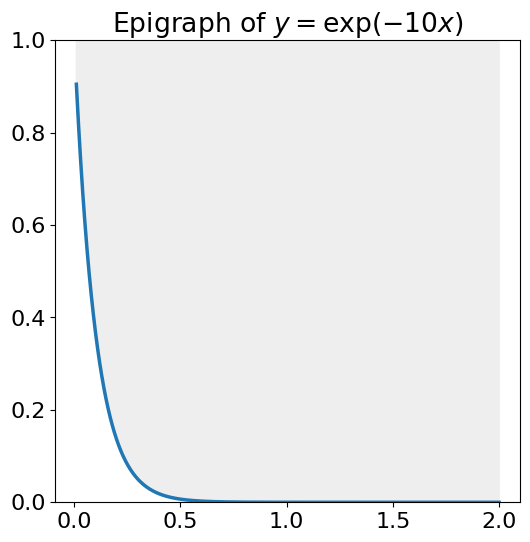

In [8]:


xs = np.linspace(0.01, 2, 1000)
ys = np.exp(-10 * xs)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of $y=\exp(-10x)$')
plt.plot(xs, ys, **kwargs)
plt.ylim(0, 1)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')





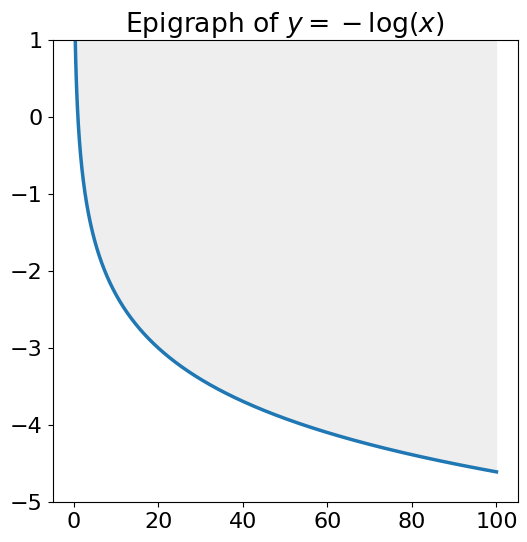

In [9]:
xs = np.linspace(0.01, 100, 10000)
ys = - np.log(xs)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of $y=-\log(x)$')
plt.plot(xs, ys, **kwargs)
plt.ylim(-5, 1)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')

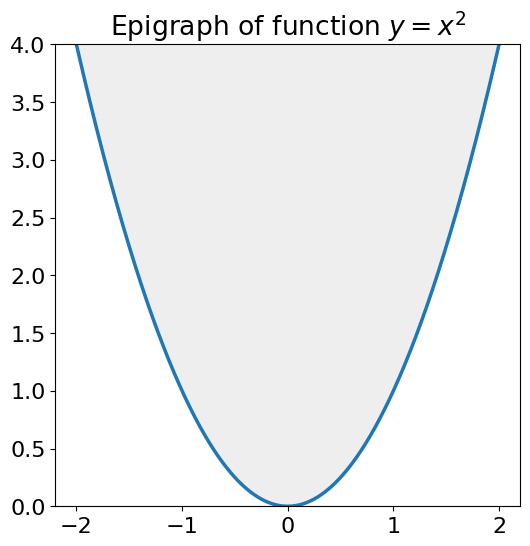

In [10]:
xs = np.linspace(-2, 2, 1000)
ys = xs**2
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of function $y =  x^2$')
plt.plot(xs, ys, **kwargs)
plt.ylim(0, 4)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')
# plt.savefig('epigraph.pdf')

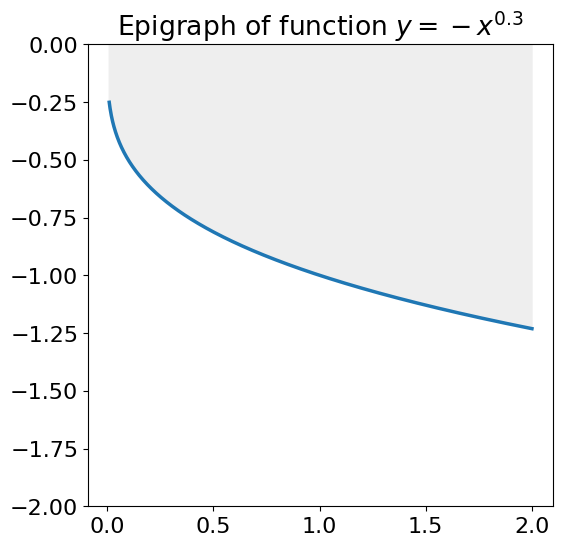

In [11]:
xs = np.linspace(0.01, 2, 1000)
ys = - np.power(xs, 0.3)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of function $y =  - x^{0.3}$')
plt.plot(xs, ys, **kwargs)
plt.ylim(-2, 0)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')


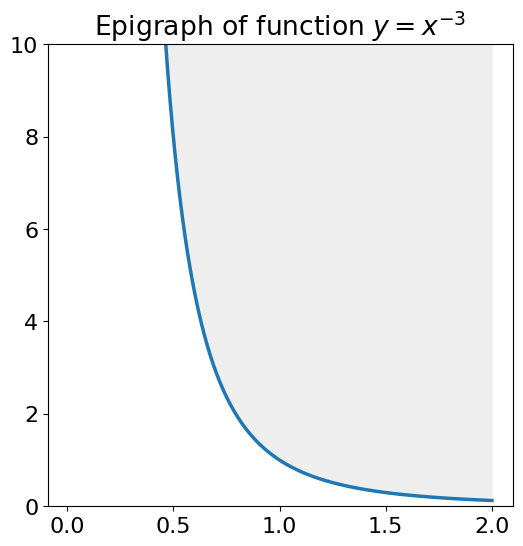

In [12]:
xs = np.linspace(0.01, 2, 1000)
ys = np.power(xs, -3)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of function $y =  x^{-3}$')
plt.plot(xs, ys, **kwargs)
plt.ylim(0, 10)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')

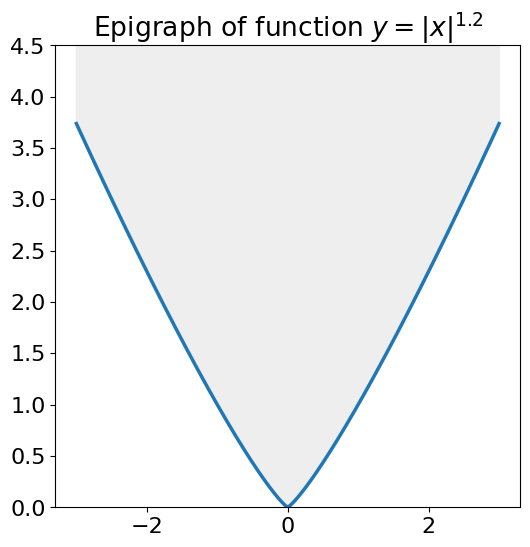

In [13]:
xs = np.linspace(-3, 3, 1000)
ys = np.power(np.abs(xs), 1.2)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of function $y =  |x|^{1.2}$')
plt.plot(xs, ys, **kwargs)
plt.ylim(0, 4.5)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')

## 3D Surface Plots of Bivariate Convex Functions

The following plots show surfaces $z = f(x,y)$ for several bivariate convex functions. A surface is convex if it "curves upward" everywhere -- more precisely, if the Hessian $\nabla^2 f(x,y) \succeq 0$ at every point. Key examples include:

- **Power functions** like $x^4 + y^4$ and $\sqrt{x^2 + y^2}$ (norms are convex).
- **Exponentials** like $e^x + e^y$ (sum of convex functions is convex).
- **Quadratics** $x^\top A x$ with $A \succeq 0$.
- **Log-sum-exp** $\log(e^x + e^y)$, which is a smooth approximation to $\max(x,y)$.
- **Quadratic-over-linear** $x^2/y$ for $y > 0$, a perspective function that is jointly convex.

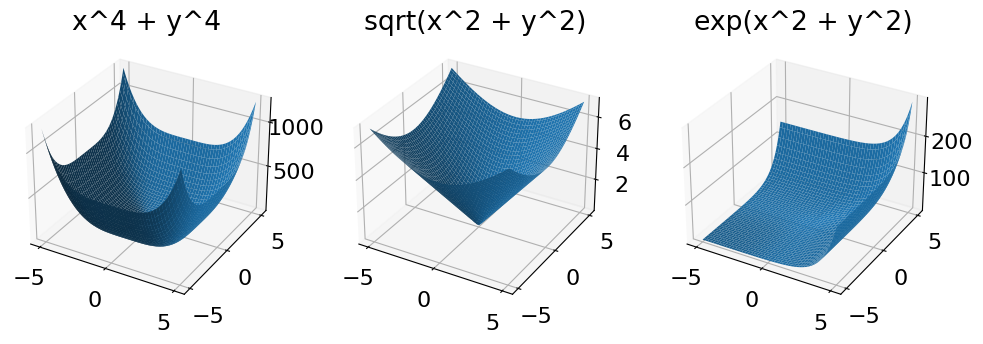

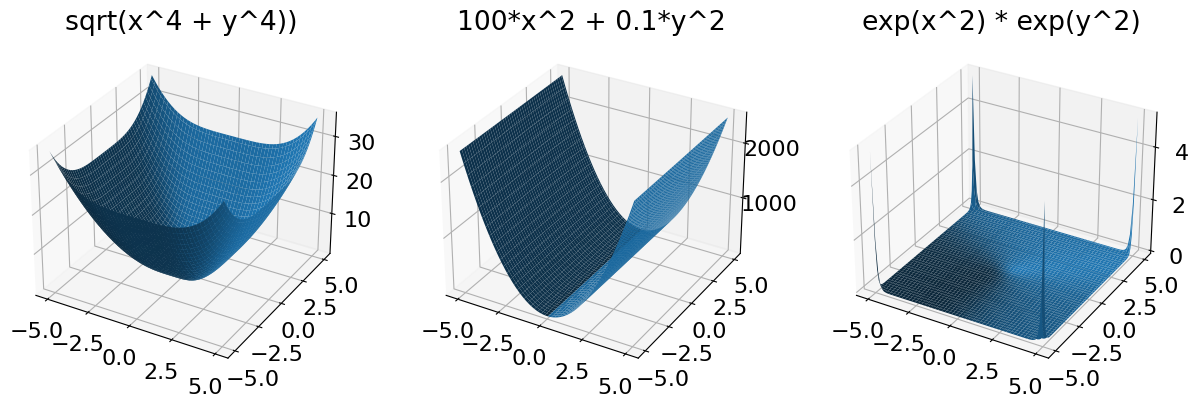

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def f1(x,y):
    return np.sqrt(x**4 + y**4 )

def f2(x,y):
    return 100* x**2 + 0.1* y**2

def f3(x,y):
    return np.exp(x**2 + y**2)



def f4(x,y):
    return x**4 + y**4

def f5(x,y):
    return np.sqrt(x**2 + y**2)

def f6(x,y):
   return np.exp(x) + np.exp(y)

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12,4))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, f4(X,Y))
ax1.set_title('x^4 + y^4')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, f5(X,Y))
ax2.set_title('sqrt(x^2 + y^2)')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X, Y, f6(X,Y))
ax3.set_title('exp(x^2 + y^2)')

plt.show()

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(15,5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, f1(X,Y))
ax1.set_title('sqrt(x^4 + y^4))')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, f2(X,Y))
ax2.set_title('100*x^2 + 0.1*y^2')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X, Y, f3(X,Y))
ax3.set_title('exp(x^2) * exp(y^2)')

plt.show()

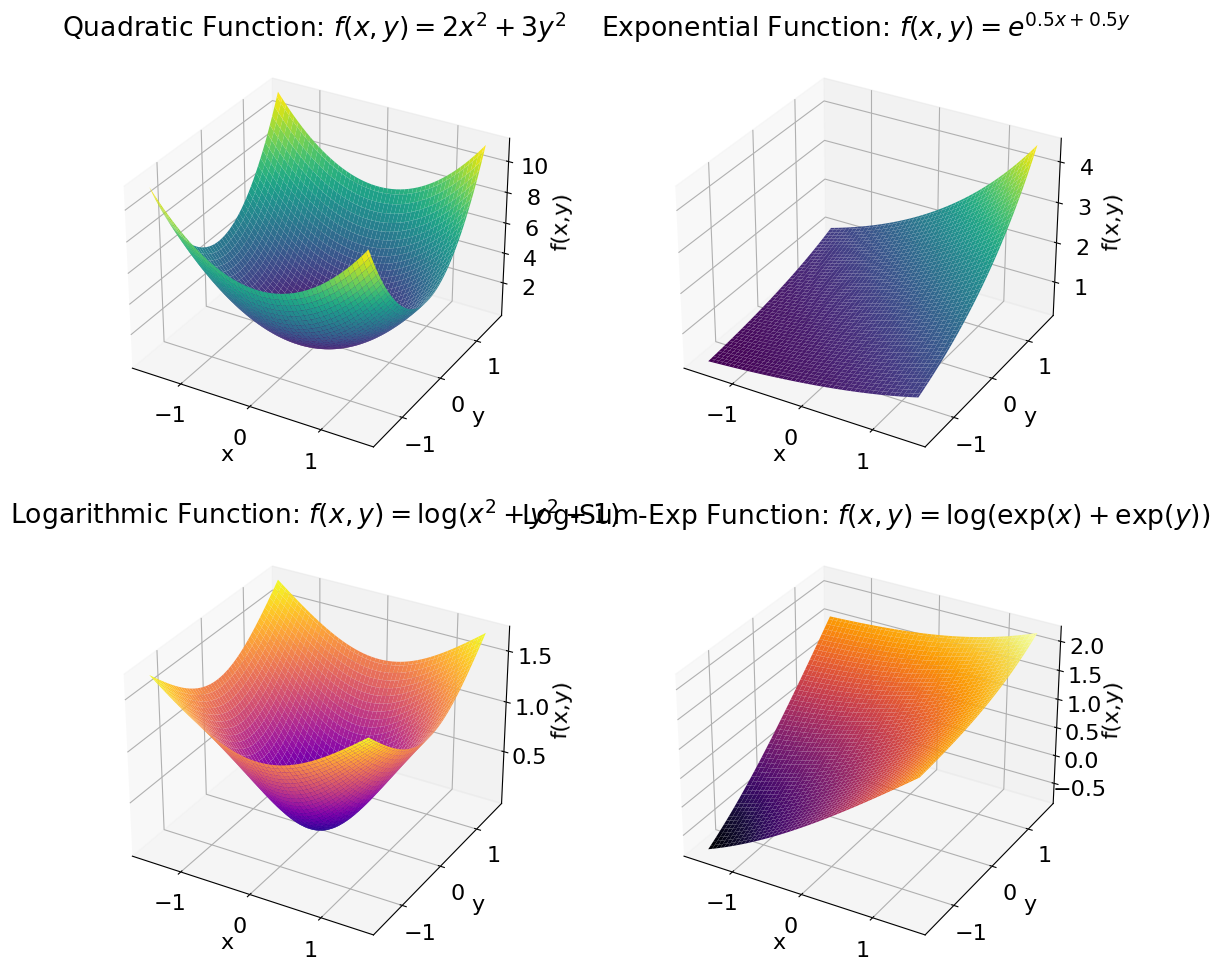

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the range of values for x, y
x_values = np.linspace(-1.5, 1.5, 100)
y_values = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x_values, y_values)

# 1. Quadratic function
Z1 = 2*X**2 + 3*Y**2

# 2. Exponential function
a, b = 0.5, 0.5
Z2 = np.exp(a*X + b*Y)

# 3. Logarithmic function
def logarithmic(x, y):
    return np.log(x**2 + y**2 + 1)

# 4. Log-Sum-Exp function
def log_sum_exp(x, y):
    return np.log(np.exp(x) + np.exp(y))

# Compute the function values for the grid
Z_logarithmic = logarithmic(X, Y)
Z_log_sum_exp = log_sum_exp(X, Y)

# Create 3D subplots for each function in a 2x2 layout
fig = plt.figure(figsize=(12, 10))

# Plot 1: Quadratic function in 3D
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z1, cmap='viridis', edgecolor='none')
ax1.set_title("Quadratic Function: $f(x,y) = 2x^2 + 3y^2$")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')

# Plot 2: Exponential function in 3D
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot_surface(X, Y, Z2, cmap='viridis', edgecolor='none')
ax2.set_title("Exponential Function: $f(x,y) = e^{0.5x + 0.5y}$")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('f(x,y)')

# Plot 3: Logarithmic function in 3D
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot_surface(X, Y, Z_logarithmic, cmap='plasma', edgecolor='none')
ax3.set_title('Logarithmic Function: $f(x, y) = \\log(x^2 + y^2 + 1)$')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('f(x,y)')

# Plot 4: Log-Sum-Exp function in 3D
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot_surface(X, Y, Z_log_sum_exp, cmap='inferno', edgecolor='none')
ax4.set_title('Log-Sum-Exp Function: $f(x, y) = \\log(\\exp(x) + \\exp(y))$')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_zlabel('f(x,y)')

# Adjust layout for a clean look
plt.tight_layout()
plt.show()


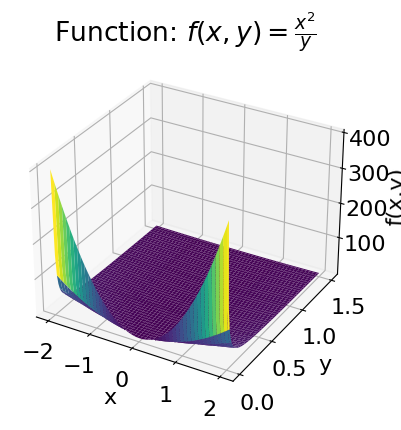

In [16]:

# Function definition
def fun_quad_over_linear(x, y):
    if np.all(y > 0):  # Ensure all y values are positive
        return x**2 / y
    else:
        raise ValueError("y must be greater than 0 to avoid division by zero or negative values")

# Define the range of values for x, y
x_values = np.linspace(-2, 2, 100)
y_values = np.linspace(0.01, 1.5, 100)  # Avoid zero to prevent division by zero
X, Y = np.meshgrid(x_values, y_values)

# Compute Z using the function
Z = fun_quad_over_linear(X, Y)

# Create 3D subplots for the function
fig = plt.figure(figsize=(12, 10))

# Plot the surface for fun_quad_over_linear
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax1.set_title(r"Function: $f(x,y) = \frac{x^2}{y}$")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')

# Show the plot
plt.show()


## Log-Determinant Is Concave

The function $f(X) = \log\det(X)$ is **concave** on the cone of positive definite matrices. This is a fundamental result used in semidefinite programming, information theory, and statistics (e.g., maximum-likelihood estimation of Gaussian covariance matrices).

We plot $\log\det(X)$ for the $2 \times 2$ matrix
$$
X = \begin{bmatrix} a & 1 \\ 1 & c \end{bmatrix},
$$
varying $(a,c)$ over the region where $\det(X) = ac - 1 > 0$. The surface curves **downward** (concave), and its sublevel sets are convex.

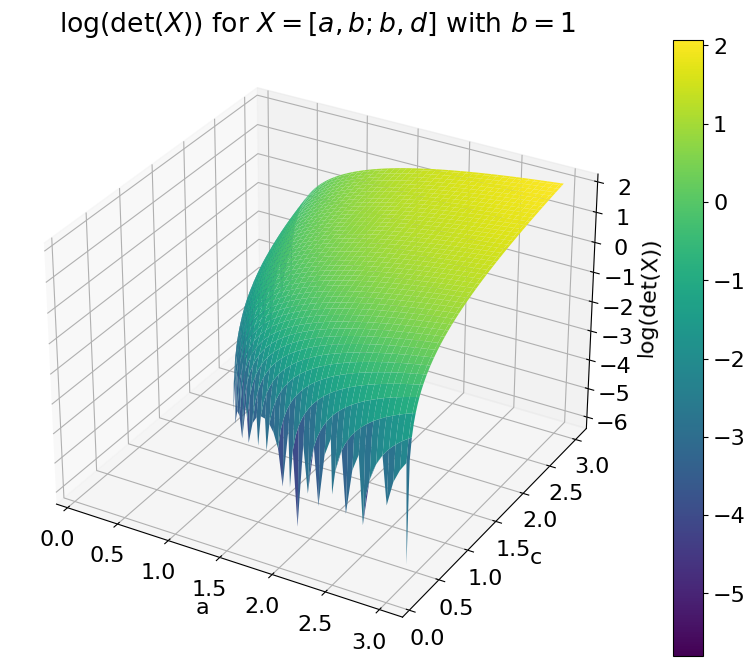

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define the log determinant function for the matrix [[a, b], [b, c]]
def logdet_general_2x2_matrix(a, b, c):
    det = a * c - b**2  # determinant of 2x2 matrix [[a, b], [b, c]]
    if np.any(det <= 0):
        raise ValueError("Determinant must be positive for log to be defined")
    return np.log(det)

# Define the range of values for a, b, and c
a_values = np.linspace(0.1, 3, 100)  # Avoiding 0 for a
c_values = np.linspace(0.1, 3, 100)  # Avoiding 0 for c
A, C = np.meshgrid(a_values, c_values)

# We'll keep b fixed for simplicity
b_fixed = 1  # You can adjust this value or make it vary as well

# Compute the log determinant
Z = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        try:
            Z[i, j] = logdet_general_2x2_matrix(A[i, j], b_fixed, C[i, j])
        except ValueError:
            Z[i, j] = np.nan  # Assign NaN if the determinant is non-positive

# Plot the surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, C, Z, cmap='viridis', edgecolor='none')

# Add titles and labels using proper LaTeX formatting
ax.set_title(r"$\log(\det(X))$ for $X =   [ a, b; b, d]$ with $b = 1$")
ax.set_xlabel('a')
ax.set_ylabel('c')
ax.set_zlabel('log(det(X))')

# Show the plot
plt.colorbar(surf)
plt.show()


The contour plot below shows the level sets of $\log\det(X)$. Because $\log\det$ is concave, its **superlevel** sets $\{X : \log\det(X) \geq \alpha\}$ are convex. In the plot, these are the regions to the upper-right of each contour line (where $a$ and $c$ are both large enough to keep the determinant large).

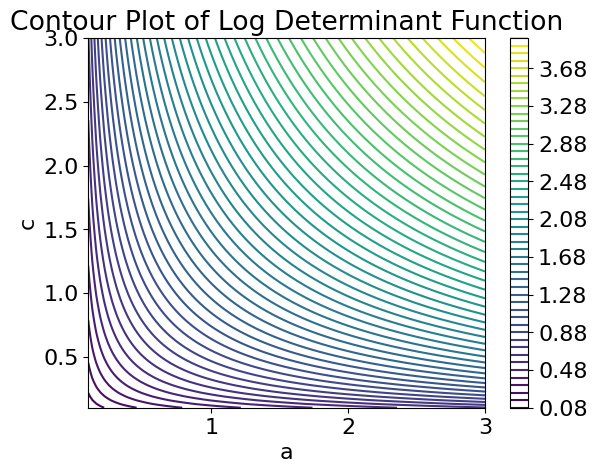

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of values for a and c
a_values = np.linspace(0.1, 3, 100)
c_values = np.linspace(0.1, 3, 100)
A, C = np.meshgrid(a_values, c_values)

# We'll keep b constant, but you can play around with different values
b = 1


# Plot Contour
plt.figure()
plt.contour(A, C, Z, 50, cmap='viridis')
plt.title("Contour Plot of Log Determinant Function")
plt.xlabel('a')
plt.ylabel('c')
plt.colorbar()
plt.show()


## Log-Sum-Exp Is Convex

The **log-sum-exp** function $f(x, y) = \log(\exp(x) + \exp(y))$ is convex. It serves as a smooth approximation to $\max(x, y)$:

$$
\max(x, y) \leq \log(\exp(x) + \exp(y)) \leq \max(x, y) + \log 2.
$$

Convexity follows because the Hessian is positive semidefinite everywhere (it can be verified by direct computation). The 3D plot below shows the characteristic "soft max" shape.

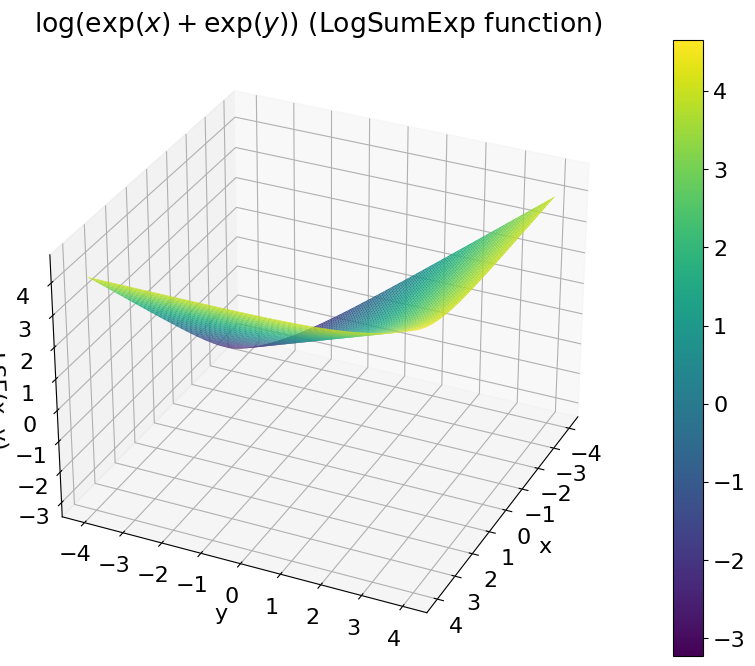

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Define the LogSumExp function
def log_sum_exp(x, y):
    return np.log(np.exp(x) + np.exp(y))

# Define the range of values for x and y
x_values = np.linspace(-4, 4, 100)
y_values = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_values, y_values)

# Compute the LogSumExp values
Z = log_sum_exp(X, Y)

# Create a 3D surface plot for LogSumExp
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.view_init(elev=30, azim=25)

# Add titles and labels
ax.set_title(r"$\log(\exp(x) + \exp(y))$ (LogSumExp function)")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('LSE(x, y)')

# Show the plot
plt.colorbar(surf)
plt.show()


## Geometric Mean Is Concave

The **geometric mean** $f(x, y) = \sqrt{xy}$ (for $x, y \geq 0$) is a **concave** function. Its surface curves downward, opposite to convex functions. Concavity of the geometric mean is a consequence of the AM--GM inequality and is used extensively in geometric programming.

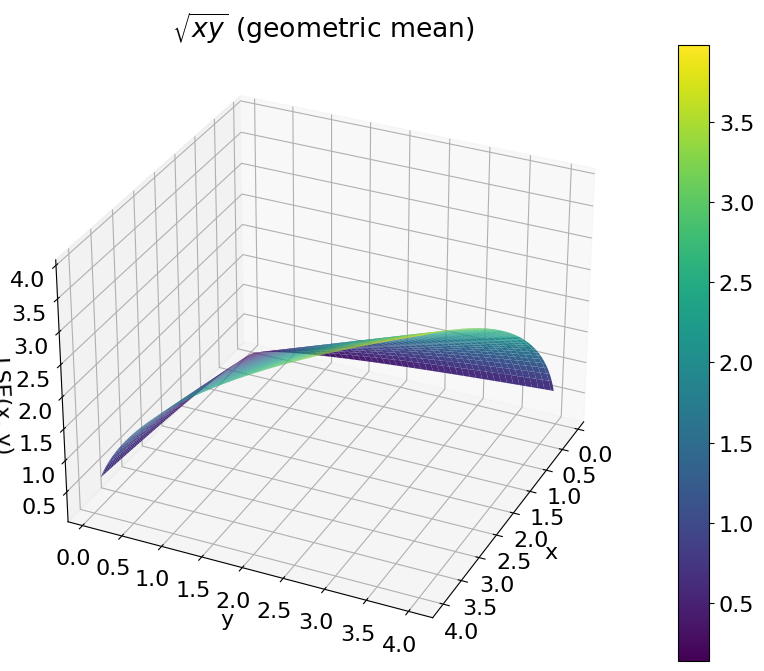

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Define the LogSumExp function
def geometric(x, y):
    if np.any(x<0) or np.any(y<0):
        raise ValueError("input has to be nonnegative")
    return np.sqrt(x*y)

# Define the range of values for x and y
x_values = np.linspace(0.1, 4, 100)
y_values = np.linspace(0.1, 4, 100)
X, Y = np.meshgrid(x_values, y_values)

# Compute the LogSumExp values
Z = geometric(X, Y)

# Create a 3D surface plot for LogSumExp
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.view_init(elev=30, azim=25)

# Add titles and labels
ax.set_title(r"$\sqrt{x y}$ (geometric mean)")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('LSE(x, y)')

# Show the plot
plt.colorbar(surf)
plt.show()

## Level Sets (Contour Plots) of Bivariate Convex Functions

The **sublevel sets** $\{x : f(x) \leq \alpha\}$ of a convex function are convex sets. Contour plots display level sets $\{x : f(x) = \alpha\}$, which bound these sublevel sets. Below we plot contours for a quadratic form, a general PSD quadratic, and the $\ell_1$-norm. Note the elliptical contours for quadratics and the diamond-shaped contours for $|x| + |y|$.

<a list of 6 text.Text objects>

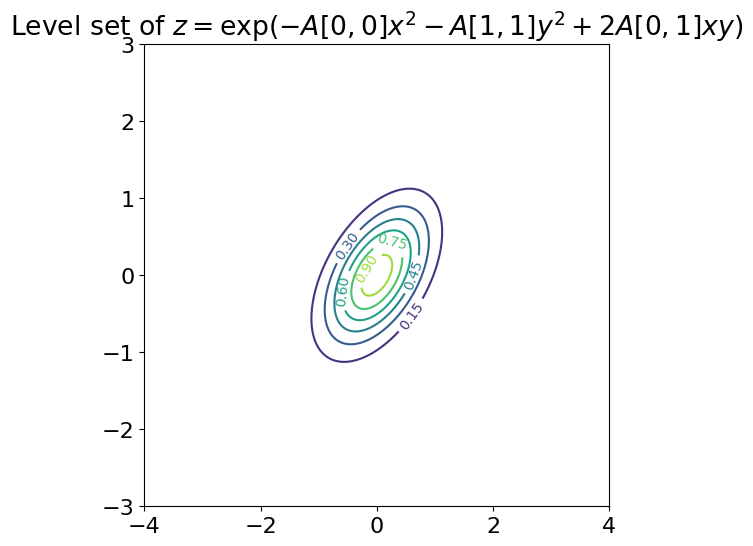

In [18]:
A = np.array([[2, 1],
            [1, 2]])

x = np.linspace(-4, 4, 1000)
y = np.linspace(-3, 3, 1000)

X, Y = np.meshgrid(x, y)
Z = np.exp(-A[0,0] *X**2 - A[1,1] * Y**2 + 2 * A[0,1 ] * X * Y)

plt.figure(1, figsize=(6, 6))

plt.title('Level set of $z  =  \exp( - A[0,0] x^2 - A[1,1] y^2 + 2 A[0,1] x y)$')
CS = plt.contour(X, Y, Z)
plt.clabel(CS, inline=True, fontsize=10)

<a list of 13 text.Text objects>

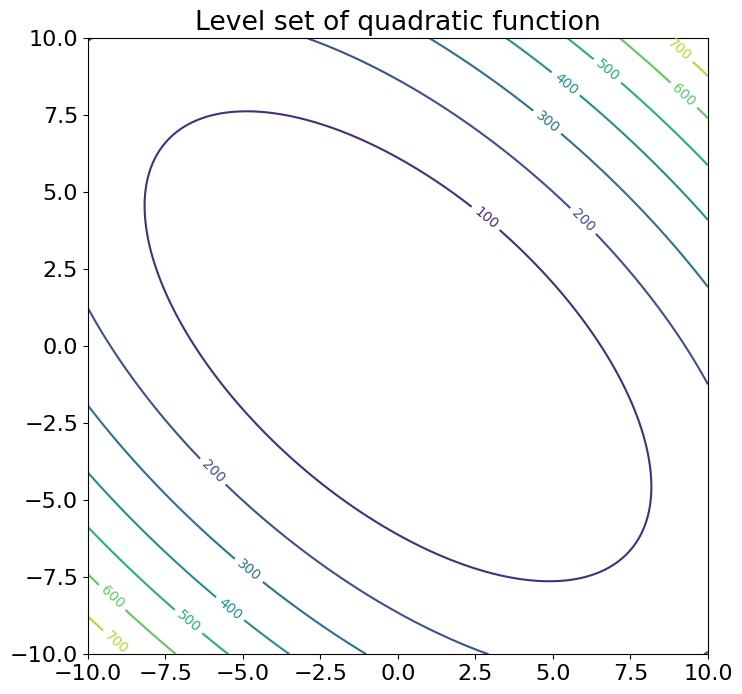

In [19]:
a = np.random.rand(2, 2)
q, r = np.linalg.qr(a) # q is a orthognoal matrix
eig = np.diag([1, 4])

A = np.matmul(np.matmul(q, eig), q.T)

x = np.linspace(-10, 10, 1000)
y = np.linspace(-10, 10, 1000)

X, Y = np.meshgrid(x, y)
Z = A[0,0] *X**2 + A[1,1] * Y**2 - 2 * A[0,1 ] * X * Y

plt.figure(1, figsize=(8,8))

plt.title('Level set of quadratic function')
CS = plt.contour(X, Y, Z)
plt.clabel(CS, inline=True, fontsize=10)

<a list of 13 text.Text objects>

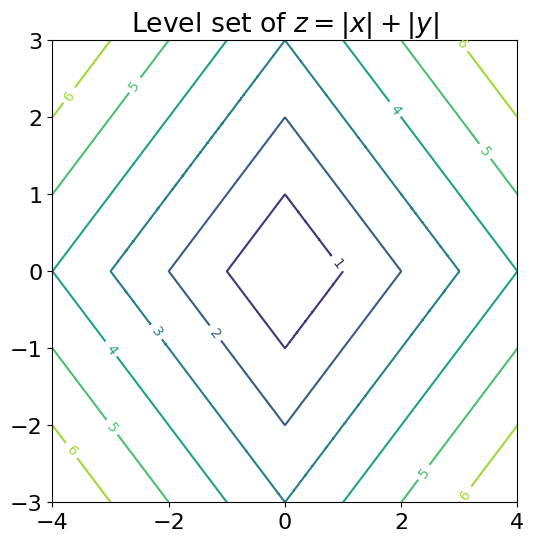

In [20]:

A = np.array([[2, 1],
            [1, 2]])

x = np.linspace(-4, 4, 1000)
y = np.linspace(-3, 3, 1000)

X, Y = np.meshgrid(x, y)
Z =  np.abs(X) +  np.abs(Y)

plt.figure(1, figsize=(6, 6))

plt.title('Level set of $z  =  |x| + |y|$')
CS = plt.contour(X, Y, Z)
plt.clabel(CS, inline=True, fontsize=10)

## First-Order Taylor Approximation of Convex Functions

For a differentiable convex function $f$, the **first-order condition** states:

$$
f(y) \geq f(x) + \nabla f(x)^\top (y - x) \quad \text{for all } x, y.
$$

The right-hand side is the first-order Taylor approximation (tangent line in 1D, tangent plane in 2D). For convex functions, this approximation is always a **global under-estimator**. Below we visualize this for univariate functions at $x=1$, and then for a bivariate exponential function $f(x,y) = e^{0.5x + 0.5y}$ where the tangent plane sits below the surface.

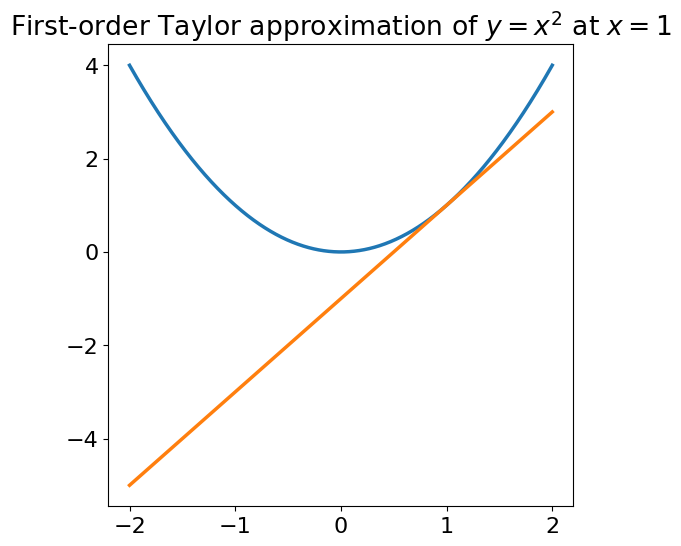

In [22]:

xs = np.linspace(-2, 2, 1000)
ys = xs**2

plt.figure(2, figsize=(6, 6))
plt.title('First-order Taylor approximation of $y = x^2$ at $x = 1$')

y1 = 1 + 2* (xs - 1)
plt.plot(xs, ys, **kwargs)
plt.plot(xs, y1, **kwargs)
# plt.savefig('taylor.pdf')

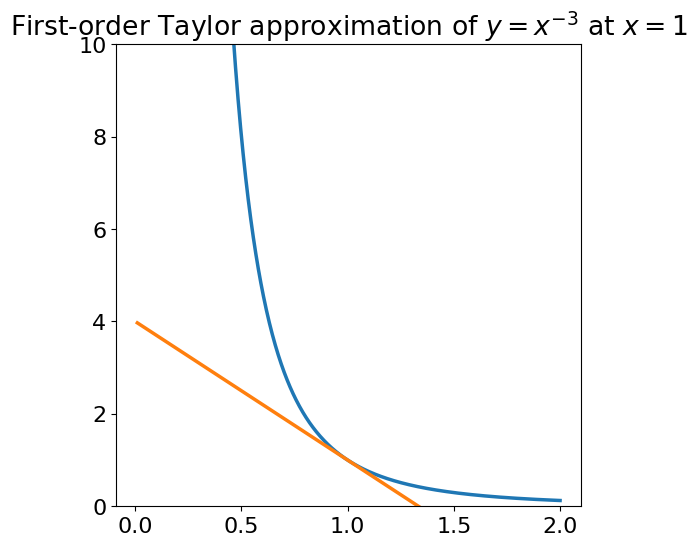

In [23]:

xs = np.linspace(0.01, 2, 1000)
ys = np.power(xs, -3)

plt.figure(2, figsize=(6, 6))
plt.title('First-order Taylor approximation of $y = x^{-3}$ at $x = 1$')

y1 = 1 + (-3)* (xs - 1)
plt.ylim(0, 10)
plt.plot(xs, ys, **kwargs)
plt.plot(xs, y1, **kwargs)
# plt.savefig('taylor.pdf')

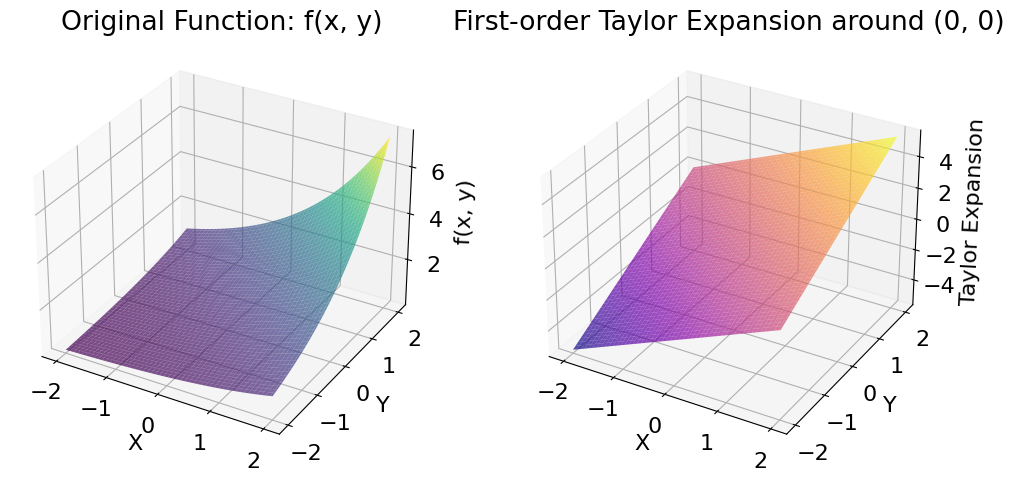

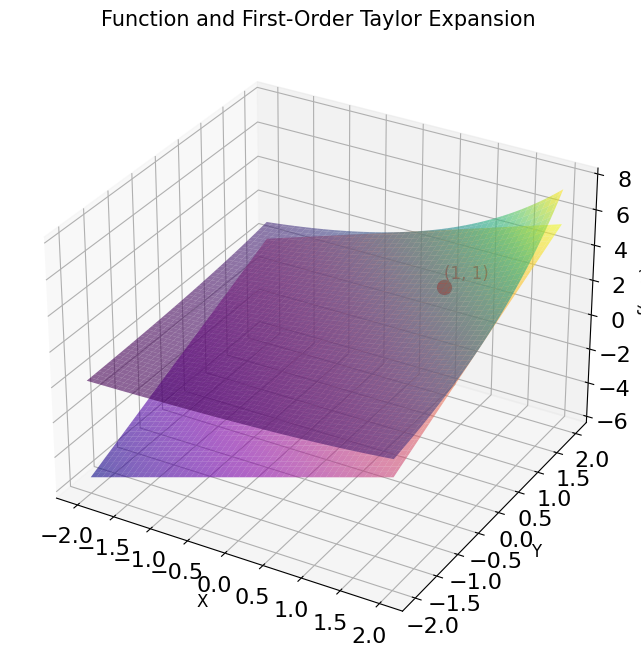

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the original function f(x, y)
def f(x, y):
    return np.exp(0.5 * x + 0.5 * y)

# Define the first-order Taylor expansion around point (x0, y0)
def taylor_expansion(x, y, x0, y0):
    f0 = f(x0, y0)
    fx = 0.5 * f(x0, y0)
    fy = 0.5 * f(x0, y0)
    return f0 + fx * (x - x0) + fy * (y - y0)

# Set up the grid for x and y
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# Compute the original function values
Z = f(X, Y)

# Compute the Taylor expansion values around (x0, y0)
x0, y0 = 1,1
Z_taylor = taylor_expansion(X, Y, x0, y0)



# Create the 3D plot
fig = plt.figure(figsize=(12, 6))

# Plot the original function
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.7)
ax.set_title('Original Function: f(x, y)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')

# Plot the first-order Taylor expansion
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X, Y, Z_taylor, cmap='plasma', edgecolor='none', alpha=0.7)
ax.set_title('First-order Taylor Expansion around (0, 0)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Taylor Expansion')

plt.show()



# Create the 3D plot
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

# Plot the original function
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.6, label="Original Function")

# Plot the Taylor expansion
ax.plot_surface(X, Y, Z_taylor, cmap='plasma', edgecolor='none', alpha=0.6, label="Taylor Expansion")

# Highlight the point (x0, y0) on both the function and Taylor expansion
ax.scatter(x0, y0, f(x0, y0), color='red', s=100, label='Point (x0, y0)', zorder=5)

# Set the title and labels
ax.set_title('Function and First-Order Taylor Expansion', fontsize=15)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('f(x, y)', fontsize=12)

# Highlight the point in the plot
ax.text(x0, y0, f(x0, y0) + 0.5, f"({x0}, {y0})", color='red', fontsize=12)

plt.show()


## Summary

**Key takeaways from this notebook:**

1. **Convex sets in 3D.** Ellipsoids, convex hulls, and polytopes (e.g., pyramids) are all convex sets. Their boundaries are smooth or piecewise-linear, with no indentations.

2. **Supporting hyperplanes.** At every boundary point of a convex set, there exists a tangent hyperplane that does not cross the interior. This is the geometric content of the supporting hyperplane theorem.

3. **Convex and concave functions.** Convex functions curve upward (bowl-shaped surfaces); concave functions curve downward. Important examples include quadratics ($A \succeq 0$), log-sum-exp (convex), geometric mean (concave), and $\log\det$ (concave).

4. **First-order condition in 2D.** The tangent plane to a convex surface always lies below the surface, providing a global under-estimator. This geometric property is the foundation of gradient descent and cutting-plane methods.